In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/Cleaned_Dataset_IntermodalRail.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 257
Columns: 19


In [3]:
df.head()

,shipment_id,transport_mode,recorded_date,recorded_time,recorded_datetime,origin_location,destination_location,cargo_type,temperature_celsius,humidity_percentage,vibration_level,pressure_kpa,exposure_duration_hours,door_open_count,salinity_ppt,thermal_leakage_score,spoilage_risk_percent,remaining_shelf_life_days,spoilage_status
0,RAIL1001,Intermodal Rail,2025-07-18,10:00,2025-07-18 10:00:00,Mumbai,Kochi,Flowers,3.8,62.4,1.8,0.0,159.2,0,0.0,4.5,20.3,4.0,Fresh
1,RAIL0681,Intermodal Rail,2025-03-01,10:45,2025-03-01 10:45:00,Kolkata,Kochi,Flowers,4.5,47.4,4.3,0.0,143.1,0,0.0,4.3,13.5,4.7,Fresh
2,RAIL0086,Intermodal Rail,2024-11-09,01:05,2024-11-09 01:05:00,Kolkata,Bengaluru,Meat,3.1,35.8,0.4,0.0,141.9,0,0.0,3.2,18.7,5.2,Fresh
3,RAIL0432,Intermodal Rail,2024-11-30,04:35,2024-11-30 04:35:00,Kolkata,Jammu,Pharmaceuticals,7.2,50.7,2.6,0.0,153.1,0,0.0,1.4,8.3,28.2,Fresh
4,RAIL0624,Intermodal Rail,2025-06-25,08:15,2025-06-25 08:15:00,Mumbai,Nagpur,Fruits,11.5,34.1,3.0,0.0,140.2,0,0.0,3.4,8.8,11.0,Fresh


In [4]:
print("Humidity column information:")
print(df["humidity_percentage"].describe())

Humidity column information:
count    257.000000
mean      61.494163
std       15.146523
min       30.000000
25%       52.000000
50%       60.400000
75%       70.700000
max       95.000000
Name: humidity_percentage, dtype: float64


In [5]:
humidity_by_spoilage = df.groupby(
    "spoilage_status"
)["humidity_percentage"].mean()

print("Average Humidity by Spoilage Status:")
print(humidity_by_spoilage)

Average Humidity by Spoilage Status:
spoilage_status
At Risk    75.767857
Fresh      60.289286
Spoiled    78.880000
Name: humidity_percentage, dtype: float64


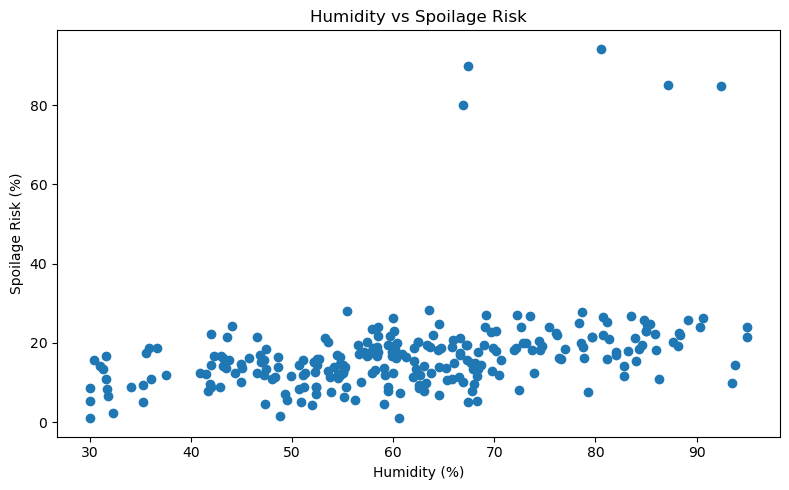

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["humidity_percentage"],
    df["spoilage_risk_percent"]
)

plt.title("Humidity vs Spoilage Risk")
plt.xlabel("Humidity (%)")
plt.ylabel("Spoilage Risk (%)")

plt.tight_layout()
plt.show()

In [7]:

humidity_risk_correlation = df[
    "humidity_percentage"
].corr(
    df["spoilage_risk_percent"]
)

print(
    "Humidity vs Spoilage Risk Correlation:",
    humidity_risk_correlation
)

Humidity vs Spoilage Risk Correlation: 0.3731967916784638


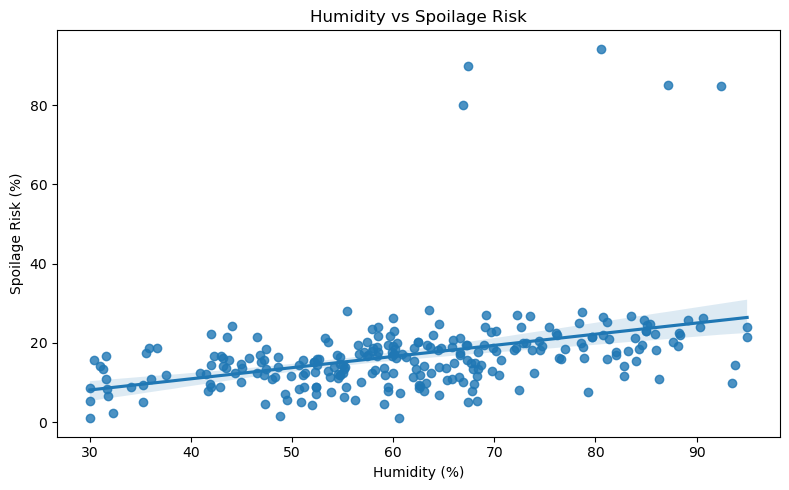

In [8]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="humidity_percentage",
    y="spoilage_risk_percent"
)

plt.title("Humidity vs Spoilage Risk")
plt.xlabel("Humidity (%)")
plt.ylabel("Spoilage Risk (%)")

plt.tight_layout()
plt.show()
